Training Data Shape: (4431, 1)

First 5 Training Values:

[[50.050049]
 [50.555557]
 [55.430431]
 [55.675674]
 [52.532532]]

X_train Shape: (4371, 60, 1)
y_train Shape: (4371,)
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0021
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.3598e-04
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.1727e-04
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.4126e-05
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.5740e-05
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.6476e-05
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.3848e-05
Epoch 8/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.0040e-05
Epoch 9/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8508e-05
Epoch 10/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5160e-05
Epoch 11/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3347e-05
Epoch 12/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5739e-05
Epoch 13/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.7829e-05
Epoch 14/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1680e-05
Epoch 15/20
137

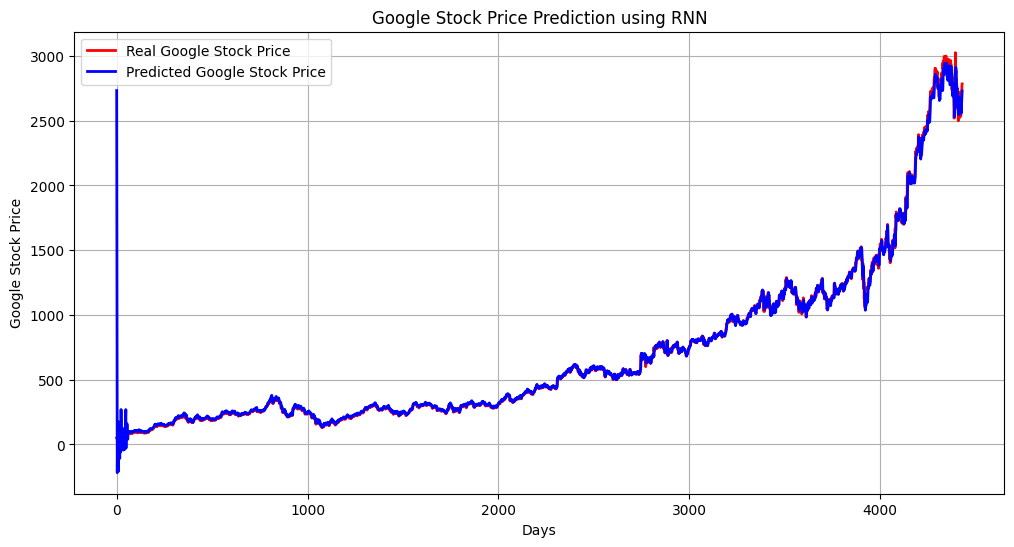

In [29]:
# Google Stock Price Prediction using RNN
# Final Updated Version with Correct Evaluation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import SimpleRNN

# ---------------- LOAD TRAIN DATA ----------------

dataset_train = pd.read_csv("GOOGL.csv")

# Use ONLY Open column
training_set = dataset_train[['Open']].values

print("Training Data Shape:", training_set.shape)

print("\nFirst 5 Training Values:\n")
print(training_set[:5])

# ---------------- FEATURE SCALING ----------------

sc = MinMaxScaler(feature_range=(0, 1))

training_set_scaled = sc.fit_transform(training_set)

# ---------------- CREATE TRAINING DATA ----------------

X_train = []
y_train = []

# Previous 60 days -> predict next day
for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

# Convert to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)

# Reshape for RNN
X_train = np.reshape(
    X_train,
    (X_train.shape[0],
     X_train.shape[1],
     1)
)

print("\nX_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

# ---------------- BUILD RNN MODEL ----------------

model = Sequential()

# RNN Layer
model.add(
    SimpleRNN(
        units=50,
        activation='tanh',
        input_shape=(X_train.shape[1], 1)
    )
)

# Output Layer
model.add(Dense(units=1))

# Compile Model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# ---------------- TRAIN MODEL ----------------

model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)

# ---------------- LOAD TEST DATA ----------------

dataset_test = pd.read_csv("GOOGL.csv")

# Real Stock Prices
real_stock_price = dataset_test[['Open']].values

print("\nTest Data Shape:", real_stock_price.shape)

print("\nFirst 5 Real Prices:\n")
print(real_stock_price[:5])

# ---------------- PREPARE TEST INPUT ----------------

dataset_total = pd.concat(
    (dataset_train['Open'],
     dataset_test['Open']),
    axis=0
)

inputs = dataset_total[
    len(dataset_total) - len(dataset_test) - 60:
].values

inputs = inputs.reshape(-1, 1)

# Scale Inputs
inputs = sc.transform(inputs)

# Create Test Sequences
X_test = []

for i in range(60, 60 + len(dataset_test)):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)

# Reshape for RNN
X_test = np.reshape(
    X_test,
    (X_test.shape[0],
     X_test.shape[1],
     1)
)

print("\nX_test Shape:", X_test.shape)

# ---------------- PREDICT STOCK PRICE ----------------

predicted_stock_price = model.predict(X_test)

# Convert back to original values
predicted_stock_price = sc.inverse_transform(
    predicted_stock_price
)

# ---------------- FLATTEN ARRAYS ----------------

real_stock_price = real_stock_price.flatten()

predicted_stock_price = predicted_stock_price.flatten()

print("\nReal Shape:", real_stock_price.shape)
print("Predicted Shape:", predicted_stock_price.shape)

# ---------------- MODEL EVALUATION ----------------

mse = mean_squared_error(
    real_stock_price,
    predicted_stock_price
)

mae = mean_absolute_error(
    real_stock_price,
    predicted_stock_price
)

rmse = np.sqrt(mse)

r2 = r2_score(
    real_stock_price,
    predicted_stock_price
)

print("\n========== MODEL EVALUATION ==========")

print("Mean Squared Error (MSE):", mse)

print("Mean Absolute Error (MAE):", mae)

print("Root Mean Squared Error (RMSE):", rmse)

print("R2 Score:", r2)

# ---------------- VISUALIZATION ----------------

plt.figure(figsize=(12,6))

# Real Prices
plt.plot(
    real_stock_price,
    color='red',
    linewidth=2,
    label='Real Google Stock Price'
)

# Predicted Prices
plt.plot(
    predicted_stock_price,
    color='blue',
    linewidth=2,
    label='Predicted Google Stock Price'
)

# Labels and Title
plt.title('Google Stock Price Prediction using RNN')

plt.xlabel('Days')

plt.ylabel('Google Stock Price')

plt.legend()

plt.grid(True)

plt.show()

In [30]:
# ---------------- USER INPUT PREDICTION ----------------

print("\nEnter Previous 10 Days Google Stock Prices")

user_input = []

# Take 60 inputs
for i in range(10):
    value = float(input(f"Day {i+1} Price: "))
    user_input.append(value)

# Convert to numpy array
user_input = np.array(user_input)

# Reshape
user_input = user_input.reshape(-1, 1)

# Scale Input
user_input_scaled = sc.transform(user_input)

# Create X_input
X_input = []

X_input.append(user_input_scaled[:, 0])

X_input = np.array(X_input)

# Reshape for RNN
X_input = np.reshape(
    X_input,
    (X_input.shape[0],
     X_input.shape[1],
     1)
)

# Predict Next Day Price
predicted_price = model.predict(X_input)

# Convert Back to Original Price
predicted_price = sc.inverse_transform(
    predicted_price
)

print("\nPredicted Next Day Google Stock Price:")

print(predicted_price[0][0])


Enter Previous 10 Days Google Stock Prices
Day 1 Price: 100
Day 2 Price: 50
Day 3 Price: 78
Day 4 Price: 95
Day 5 Price: 47
Day 6 Price: 96
Day 7 Price: 87
Day 8 Price: 102
Day 9 Price: 120
Day 10 Price: 80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step

Predicted Next Day Google Stock Price:
107.747574
